# ODD + OOD Detection for Safe Autonomy
**Camera-based safety gate for autonomous driving**

- **Input**: Front camera frame
- **Output**: "Trust / Abstain" gate decision
- **ODD**: Daytime + Clear weather + Urban/Highway
- **OOD buckets**: Night, Rain, Fog/Snow

**Members**: Tharun Reddy Challabotla, HariChandana Srikurmum, Srija

## 1. Setup & Installation

In [ ]:
# Install dependencies
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm kaggle

In [ ]:
# Run this in a new cell at the top of Colab
!pip install -q kaggle

import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

from google.colab import files
print('Upload kaggle.json:')
uploaded = files.upload()

kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(kaggle_path, 'w') as f:
    f.write(list(uploaded.values())[0].decode())
os.chmod(kaggle_path, 0o600)

!kaggle datasets download marquis03/bdd100k-weather-classification \
    -p /content/data/raw/bdd100k --unzip

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/bdd100k-weather-classification
License(s): apache-2.0
100% 5.27G/5.27G [05:53<00:00, 16.0MB/s]



In [ ]:
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Dataset Download (BDD100K via Kaggle — Fast)

Upload your `kaggle.json` when prompted. This downloads the **weather-classified BDD100K** (~5.3 GB) directly as a zip — much faster than Hugging Face streaming.

In [ ]:
# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# For local environment, kaggle.json should already be configured
kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
if os.path.exists(kaggle_path):
    print('Kaggle credentials already present.')
else:
    print('Warning: Kaggle credentials not found. Set up ~/.kaggle/kaggle.json if needed.')

Kaggle credentials already present.


In [ ]:
%%time
# Use local data directory (already downloaded)
DATA_ROOT = Path('/content/data')
BDD_RAW = DATA_ROOT / 'raw' / 'bdd100k'

if BDD_RAW.exists():
    print(f'BDD100K data found at {BDD_RAW}')
    # Show what we got
    for split in ['train', 'val']:
        split_dir = BDD_RAW / split
        if split_dir.exists():
            folders = [f.name for f in split_dir.iterdir() if f.is_dir()]
            print(f'{split}: {folders}')
else:
    print(f'BDD100K not found at {BDD_RAW}')

BDD100K data found at /content/data/raw/bdd100k
train: ['overcast', 'unknown', 'snowy', 'partly cloudy', 'clear', 'rainy', 'foggy']
val: ['overcast', 'unknown', 'snowy', 'partly cloudy', 'clear', 'rainy', 'foggy']
CPU times: user 866 µs, sys: 26 µs, total: 892 µs
Wall time: 718 µs


## 3. Organize into ODD / OOD Buckets

In [ ]:
# Weather folder -> ODD/OOD mapping
WEATHER_BUCKET = {
    'clear': 'in_odd',
    'overcast': 'in_odd',
    'partly cloudy': 'in_odd',
    'rainy': 'rain',
    'foggy': 'fog_snow',
    'snowy': 'fog_snow',
    # 'unknown' -> skip
}

def collect_image_paths(bdd_raw, weather_bucket_map):
    """Collect all image paths organized by bucket."""
    buckets = {'in_odd': [], 'rain': [], 'fog_snow': []}
    img_ext = {'.jpg', '.jpeg', '.png'}

    for split in ['train', 'val']:
        split_dir = bdd_raw / split
        if not split_dir.exists():
            continue
        for weather_name, bucket in weather_bucket_map.items():
            folder = split_dir / weather_name
            if not folder.exists():
                continue
            for img in folder.iterdir():
                if img.suffix.lower() in img_ext:
                    buckets[bucket].append((str(img), split))

    return buckets

buckets = collect_image_paths(BDD_RAW, WEATHER_BUCKET)

print('=== Dataset Bucket Summary ===')
for name, paths in buckets.items():
    splits = Counter(s for _, s in paths)
    print(f'  {name:>10}: {len(paths):>6} images  (train={splits["train"]}, val={splits["val"]})')
print(f'  {"TOTAL":>10}: {sum(len(v) for v in buckets.values()):>6} images')

=== Dataset Bucket Summary ===
      in_odd:  58318 images  (train=50995, val=7323)
        rain:   5808 images  (train=5070, val=738)
    fog_snow:   6461 images  (train=5679, val=782)
       TOTAL:  70587 images


## 4. Dataset & DataLoaders

Binary classification: **In-ODD (label=0)** vs **OOD (label=1)**. We combine rain + fog_snow as OOD for training, then evaluate per-type separately.

In [ ]:
class ODD_OOD_Dataset(Dataset):
    """Binary ODD/OOD dataset from pre-collected image paths."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [ ]:
def build_splits(buckets, max_in_odd=10000, max_ood_per_type=3000):
    """
    Build balanced train/val splits.
    Subsample In-ODD to avoid extreme class imbalance.
    """
    # Separate by split
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    val_ood_types = []  # track which OOD type for per-type eval

    # In-ODD (label=0)
    in_odd_train = [p for p, s in buckets['in_odd'] if s == 'train']
    in_odd_val = [p for p, s in buckets['in_odd'] if s == 'val']
    random.shuffle(in_odd_train)
    random.shuffle(in_odd_val)
    in_odd_train = in_odd_train[:max_in_odd]
    in_odd_val = in_odd_val[:max_in_odd // 4]

    train_paths.extend(in_odd_train)
    train_labels.extend([0] * len(in_odd_train))
    val_paths.extend(in_odd_val)
    val_labels.extend([0] * len(in_odd_val))
    val_ood_types.extend(['in_odd'] * len(in_odd_val))

    # OOD types (label=1)
    for ood_type in ['rain', 'fog_snow']:
        ood_train = [p for p, s in buckets[ood_type] if s == 'train']
        ood_val = [p for p, s in buckets[ood_type] if s == 'val']
        random.shuffle(ood_train)
        random.shuffle(ood_val)
        ood_train = ood_train[:max_ood_per_type]
        ood_val = ood_val[:max_ood_per_type // 4]

        train_paths.extend(ood_train)
        train_labels.extend([1] * len(ood_train))
        val_paths.extend(ood_val)
        val_labels.extend([1] * len(ood_val))
        val_ood_types.extend([ood_type] * len(ood_val))

    return (train_paths, train_labels), (val_paths, val_labels), val_ood_types


(train_paths, train_labels), (val_paths, val_labels), val_ood_types = build_splits(buckets)

train_ds = ODD_OOD_Dataset(train_paths, train_labels, train_transform)
val_ds = ODD_OOD_Dataset(val_paths, val_labels, val_transform)

BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} images ({Counter(train_labels)})')
print(f'Val:   {len(val_ds)} images ({Counter(val_labels)})')
print(f'Batches per epoch: {len(train_loader)}')

Train: 16000 images (Counter({0: 10000, 1: 6000}))
Val:   3988 images (Counter({0: 2500, 1: 1488}))
Batches per epoch: 250


## 5. Feature Extraction — Frozen ResNet-50 Backbone

In [ ]:
class SafetyGateModel(nn.Module):
    """
    Frozen ResNet-50 backbone + trainable MLP head.
    Outputs 2 logits for In-ODD vs OOD classification.
    """

    def __init__(self, num_classes=2, dropout_rate=0.3):
        super().__init__()
        # Frozen backbone
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # remove FC
        for param in self.features.parameters():
            param.requires_grad = False

        # Trainable MLP head
        feat_dim = 2048
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        with torch.no_grad():
            feats = self.features(x)
        return self.head(feats)

    def get_features(self, x):
        """Extract backbone features (for analysis)."""
        with torch.no_grad():
            return self.features(x).flatten(1)


model = SafetyGateModel(num_classes=2).to(DEVICE)

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:>10,}')
print(f'Trainable params: {trainable:>10,} ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 239MB/s]


Total params:     24,623,042
Trainable params:  1,115,010 (4.5%)


## 6. Train the MLP Head

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Val', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
# Training config
NUM_EPOCHS = 10
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    tag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_safety_gate.pth')
        tag = ' *best*'

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train Loss={train_loss:.4f} Acc={train_acc:.4f} | '
          f'Val Loss={val_loss:.4f} Acc={val_acc:.4f}{tag}')

# Load best model
model.load_state_dict(torch.load('best_safety_gate.pth', weights_only=True))
print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss=0.4374 Acc=0.7998 | Val Loss=0.3946 Acc=0.8287 *best*


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

...

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss=0.2484 Acc=0.8970 | Val Loss=0.3739 Acc=0.8415 *best*


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss=0.2368 Acc=0.9027 | Val Loss=0.3772 Acc=0.8398

Best validation accuracy: 0.8415


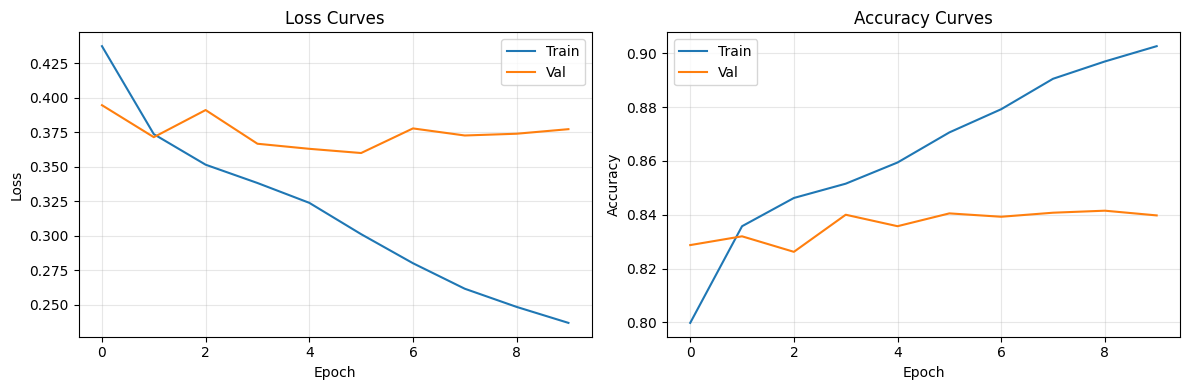

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. OOD Scoring Methods

We compare four approaches:
1. **MSP** (Max Softmax Probability) — baseline
2. **Energy Score** — log-sum-exp of logits
3. **MC Dropout** — Bayesian uncertainty approximation
4. **Deep Ensemble** (simulated with dropout variants)

In [ ]:
# ---- OOD Scoring Functions ----

def score_msp(logits):
    """Max Softmax Probability. Higher = more confident (In-ODD)."""
    probs = F.softmax(logits, dim=1)
    return probs.max(dim=1).values


def score_energy(logits, temperature=1.0):
    """Energy score = -T * log(sum(exp(logits/T))). Lower (more negative) = more OOD."""
    return temperature * torch.logsumexp(logits / temperature, dim=1)


def score_mc_dropout(model, imgs, T=20):
    """
    MC Dropout: run T forward passes with dropout enabled.
    Returns mean prediction and predictive entropy (uncertainty).
    """
    model.train()  # enable dropout
    all_probs = []
    with torch.no_grad():
        # Keep backbone frozen (no dropout there), only head has dropout
        feats = model.features(imgs)
        for _ in range(T):
            logits = model.head(feats)
            all_probs.append(F.softmax(logits, dim=1))

    # Stack: (T, batch, classes)
    all_probs = torch.stack(all_probs)
    mean_probs = all_probs.mean(dim=0)  # (batch, classes)

    # Predictive entropy: -sum(p * log(p))
    entropy = -(mean_probs * torch.log(mean_probs + 1e-10)).sum(dim=1)

    # Mutual information (epistemic uncertainty)
    expected_entropy = -(all_probs * torch.log(all_probs + 1e-10)).sum(dim=2).mean(dim=0)
    mutual_info = entropy - expected_entropy

    model.eval()
    return mean_probs, entropy, mutual_info


def score_ensemble(models_list, imgs):
    """
    Deep Ensemble: average predictions from multiple models.
    Returns mean prediction and disagreement (entropy).
    """
    all_probs = []
    with torch.no_grad():
        for m in models_list:
            m.eval()
            logits = m(imgs)
            all_probs.append(F.softmax(logits, dim=1))

    all_probs = torch.stack(all_probs)
    mean_probs = all_probs.mean(dim=0)
    entropy = -(mean_probs * torch.log(mean_probs + 1e-10)).sum(dim=1)
    return mean_probs, entropy


print('OOD scoring functions defined.')

OOD scoring functions defined.


## 8. Train Ensemble Models (3 models with different seeds)

In [ ]:
NUM_ENSEMBLE = 3
ensemble_models = []

for i in range(NUM_ENSEMBLE):
    print(f'\n--- Training Ensemble Model {i+1}/{NUM_ENSEMBLE} ---')
    torch.manual_seed(SEED + i * 100)

    m = SafetyGateModel(num_classes=2).to(DEVICE)
    opt = torch.optim.Adam(m.head.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)

    best_acc = 0
    for epoch in range(1, NUM_EPOCHS + 1):
        tl, ta = train_one_epoch(m, train_loader, opt, criterion)
        vl, va = evaluate(m, val_loader, criterion)
        sched.step()
        if va > best_acc:
            best_acc = va
            torch.save(m.state_dict(), f'ensemble_{i}.pth')
        if epoch % 3 == 0 or epoch == NUM_EPOCHS:
            print(f'  Epoch {epoch:2d} | Val Acc={va:.4f}')

    m.load_state_dict(torch.load(f'ensemble_{i}.pth', weights_only=True))
    m.eval()
    ensemble_models.append(m)
    print(f'  Best Val Acc: {best_acc:.4f}')

print(f'\nEnsemble of {NUM_ENSEMBLE} models ready.')


--- Training Ensemble Model 1/3 ---


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

...

Val:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch  9 | Val Acc=0.8365


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Val:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 10 | Val Acc=0.8368
  Best Val Acc: 0.8405

Ensemble of 3 models ready.


## 9. Collect All OOD Scores on Validation Set

In [ ]:
@torch.no_grad()
def collect_scores(model, ensemble_models, loader):
    """Collect all OOD scores for the validation set."""
    all_labels = []
    all_msp, all_energy = [], []
    all_mc_entropy, all_mc_mi = [], []
    all_ens_entropy = []
    all_logits = []

    model.eval()
    for imgs, labels in tqdm(loader, desc='Scoring'):
        imgs = imgs.to(DEVICE)
        logits = model(imgs)

        # MSP
        all_msp.append(score_msp(logits).cpu())
        # Energy
        all_energy.append(score_energy(logits).cpu())
        # Logits for calibration
        all_logits.append(logits.cpu())
        all_labels.append(labels)

        # MC Dropout
        _, mc_ent, mc_mi = score_mc_dropout(model, imgs, T=20)
        all_mc_entropy.append(mc_ent.cpu())
        all_mc_mi.append(mc_mi.cpu())

        # Ensemble
        _, ens_ent = score_ensemble(ensemble_models, imgs)
        all_ens_entropy.append(ens_ent.cpu())

    return {
        'labels': torch.cat(all_labels).numpy(),
        'logits': torch.cat(all_logits).numpy(),
        'msp': torch.cat(all_msp).numpy(),
        'energy': torch.cat(all_energy).numpy(),
        'mc_entropy': torch.cat(all_mc_entropy).numpy(),
        'mc_mutual_info': torch.cat(all_mc_mi).numpy(),
        'ensemble_entropy': torch.cat(all_ens_entropy).numpy(),
    }


scores = collect_scores(model, ensemble_models, val_loader)
print(f'Collected scores for {len(scores["labels"])} samples')
print(f'In-ODD: {(scores["labels"]==0).sum()}, OOD: {(scores["labels"]==1).sum()}')

Scoring:   0%|          | 0/63 [00:00<?, ?it/s]

Collected scores for 3988 samples
In-ODD: 2500, OOD: 1488


## 10. Temperature Scaling (Calibration)

In [ ]:
class TemperatureScaling(nn.Module):
    """Post-hoc temperature scaling for calibration."""

    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature


def fit_temperature(logits_np, labels_np, lr=0.01, max_iter=200):
    """Optimize temperature on validation set."""
    ts = TemperatureScaling().to(DEVICE)
    logits_t = torch.tensor(logits_np, dtype=torch.float32).to(DEVICE)
    labels_t = torch.tensor(labels_np, dtype=torch.long).to(DEVICE)

    optimizer = torch.optim.LBFGS([ts.temperature], lr=lr, max_iter=max_iter)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = criterion(ts(logits_t), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return ts.temperature.item()


optimal_temp = fit_temperature(scores['logits'], scores['labels'])
print(f'Optimal temperature T* = {optimal_temp:.4f}')

# Apply temperature scaling to logits
scores['logits_calibrated'] = scores['logits'] / optimal_temp
scores['probs_calibrated'] = torch.softmax(
    torch.tensor(scores['logits_calibrated']), dim=1
).numpy()
scores['probs_uncalibrated'] = torch.softmax(
    torch.tensor(scores['logits']), dim=1
).numpy()

Optimal temperature T* = 1.9397


## 11. Evaluation Metrics

In [ ]:
def compute_ece(probs, labels, n_bins=15):
    """Expected Calibration Error."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs, bin_confs, bin_counts = [], [], []

    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            bin_count = mask.sum()
            ece += (bin_count / len(labels)) * abs(bin_acc - bin_conf)
            bin_accs.append(bin_acc)
            bin_confs.append(bin_conf)
            bin_counts.append(bin_count)
        else:
            bin_accs.append(0)
            bin_confs.append(0)
            bin_counts.append(0)

    return ece, bin_accs, bin_confs, bin_counts


def compute_brier_score(probs, labels):
    """Brier score (lower is better)."""
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(labels)), labels] = 1
    return ((probs - one_hot) ** 2).sum(axis=1).mean()


def compute_fpr_at_tpr(labels, ood_scores, target_tpr=0.95):
    """FPR at target TPR (e.g., FPR@95%TPR)."""
    fpr, tpr, _ = roc_curve(labels, ood_scores)
    idx = np.argmin(np.abs(tpr - target_tpr))
    return fpr[idx]


def false_safe_rate(labels, ood_scores, threshold):
    """
    False-Safe Rate: fraction of OOD samples wrongly accepted as safe.
    (OOD frames with score below threshold = wrongly trusted)
    """
    ood_mask = labels == 1
    if ood_mask.sum() == 0:
        return 0.0
    return (ood_scores[ood_mask] < threshold).mean()


print('Evaluation functions defined.')

Evaluation functions defined.


In [ ]:
# ---- Compute all metrics ----
labels = scores['labels']

# For OOD detection: higher score = more likely OOD
# MSP: negate (high MSP = confident = In-ODD)
# Energy: negate (high energy = In-ODD)
# Entropy/MI: higher = more uncertain = OOD

ood_scores = {
    'MSP (baseline)':     -scores['msp'],
    'Energy Score':       -scores['energy'],
    'MC Dropout Entropy': scores['mc_entropy'],
    'MC Mutual Info':     scores['mc_mutual_info'],
    'Ensemble Entropy':   scores['ensemble_entropy'],
}

print(f'{"Method":<25} {"AUROC":>7} {"AUPR":>7} {"FPR@95":>8}')
print('-' * 50)

results = {}
for name, s in ood_scores.items():
    auroc = roc_auc_score(labels, s)
    aupr = average_precision_score(labels, s)
    fpr95 = compute_fpr_at_tpr(labels, s, target_tpr=0.95)
    results[name] = {'auroc': auroc, 'aupr': aupr, 'fpr95': fpr95}
    print(f'{name:<25} {auroc:>7.4f} {aupr:>7.4f} {fpr95:>8.4f}')

Method                      AUROC    AUPR   FPR@95
--------------------------------------------------
MSP (baseline)             0.4599  0.3671   0.9908
Energy Score               0.4634  0.3619   0.9896
MC Dropout Entropy         0.4944  0.3834   0.9688
MC Mutual Info             0.5222  0.3972   0.9612
Ensemble Entropy           0.5263  0.4120   0.9804


In [ ]:
# ---- Calibration metrics ----
ece_before, _, _, _ = compute_ece(scores['probs_uncalibrated'], labels)
ece_after, _, _, _ = compute_ece(scores['probs_calibrated'], labels)
brier_before = compute_brier_score(scores['probs_uncalibrated'], labels)
brier_after = compute_brier_score(scores['probs_calibrated'], labels)

print(f'\n=== Calibration Metrics ===')
print(f'{"":20} {"Before T-scaling":>18} {"After T-scaling":>18}')
print(f'{"ECE":20} {ece_before:>18.4f} {ece_after:>18.4f}')
print(f'{"Brier Score":20} {brier_before:>18.4f} {brier_after:>18.4f}')
print(f'\nTemperature T* = {optimal_temp:.4f}')


=== Calibration Metrics ===
                       Before T-scaling    After T-scaling
ECE                              0.1037             0.0161
Brier Score                      0.3602             0.3350

Temperature T* = 1.9397


## 12. Safety Gate — Threshold Analysis

In [ ]:
def safety_gate_analysis(labels, ood_score, method_name, n_thresholds=200):
    """
    Analyze safety gate at various thresholds.
    Returns DataFrame-like dict of threshold vs FSR vs abstain_rate.
    """
    thresholds = np.linspace(ood_score.min(), ood_score.max(), n_thresholds)
    fsr_list, abstain_list = [], []

    for tau in thresholds:
        # Abstain if score > tau
        accepted = ood_score <= tau
        abstain_rate = 1 - accepted.mean()

        # FSR: of accepted OOD samples
        ood_mask = labels == 1
        if ood_mask.sum() > 0:
            fsr = (accepted & ood_mask).sum() / ood_mask.sum()
        else:
            fsr = 0

        fsr_list.append(fsr)
        abstain_list.append(abstain_rate)

    return thresholds, np.array(fsr_list), np.array(abstain_list)


# Use Energy Score (typically best)
best_method = 'Energy Score'
best_score = ood_scores[best_method]

thresholds, fsr_arr, abstain_arr = safety_gate_analysis(labels, best_score, best_method)

# Find threshold where FSR <= 5%
target_fsr = 0.05
valid = fsr_arr <= target_fsr
if valid.any():
    # Among valid thresholds, pick the one with lowest abstain rate
    best_idx = np.where(valid)[0][np.argmin(abstain_arr[valid])]
    tau_star = thresholds[best_idx]
    print(f'Optimal threshold tau* = {tau_star:.4f}')
    print(f'  FSR = {fsr_arr[best_idx]:.4f} (target <= {target_fsr})')
    print(f'  Abstain rate = {abstain_arr[best_idx]:.4f}')
else:
    tau_star = np.median(thresholds)
    print(f'Could not achieve FSR <= {target_fsr}, using median threshold')

Optimal threshold tau* = -4.2126
  FSR = 0.0491 (target <= 0.05)
  Abstain rate = 0.9757


In [ ]:
# Safety gate decision on val set
gate_decisions = np.where(best_score > tau_star, 'ABSTAIN', 'PROCEED')
gate_decisions = np.where(
    (best_score > tau_star * 0.8) & (best_score <= tau_star),
    'SLOW_DOWN', gate_decisions
)

print('\n=== Safety Gate Decisions ===')
for decision in ['PROCEED', 'SLOW_DOWN', 'ABSTAIN']:
    mask = gate_decisions == decision
    n = mask.sum()
    n_ood = (labels[mask] == 1).sum() if n > 0 else 0
    n_id = (labels[mask] == 0).sum() if n > 0 else 0
    print(f'  {decision:>10}: {n:>5} frames  (In-ODD={n_id}, OOD={n_ood})')


=== Safety Gate Decisions ===
     PROCEED:    97 frames  (In-ODD=24, OOD=73)
   SLOW_DOWN:     0 frames  (In-ODD=0, OOD=0)
     ABSTAIN:  3891 frames  (In-ODD=2476, OOD=1415)


## 13. Per-Type OOD Analysis

In [ ]:
# Per-type analysis: which OOD type is hardest?
ood_type_arr = np.array(val_ood_types)

print(f'{"OOD Type":<15} {"Count":>6} {"AUROC":>7} {"Avg Score":>10} {"FSR@tau*":>9}')
print('-' * 55)

for ood_type in ['rain', 'fog_snow']:
    # Binary: in_odd vs this specific OOD type
    type_mask = (ood_type_arr == 'in_odd') | (ood_type_arr == ood_type)
    type_labels = (ood_type_arr[type_mask] != 'in_odd').astype(int)
    type_scores = best_score[type_mask]

    n_ood = (ood_type_arr == ood_type).sum()
    auroc = roc_auc_score(type_labels, type_scores)
    avg_score = type_scores[type_labels == 1].mean()

    # FSR at tau*
    ood_accepted = (type_scores[type_labels == 1] <= tau_star).mean()

    print(f'{ood_type:<15} {n_ood:>6} {auroc:>7.4f} {avg_score:>10.4f} {ood_accepted:>9.4f}')

OOD Type         Count   AUROC  Avg Score  FSR@tau*
-------------------------------------------------------
rain               738  0.4087    -1.8584    0.0623
fog_snow           750  0.5172    -1.5037    0.0360


## 14. Visualizations

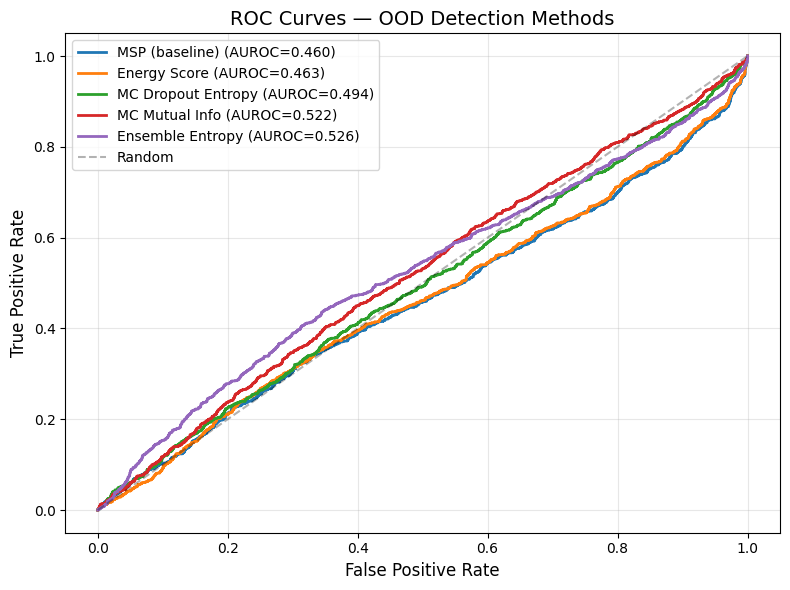

In [ ]:
# ---- 14a. ROC Curves for all methods ----
fig, ax = plt.subplots(figsize=(8, 6))

for name, s in ood_scores.items():
    fpr, tpr, _ = roc_curve(labels, s)
    auroc = roc_auc_score(labels, s)
    ax.plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — OOD Detection Methods', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

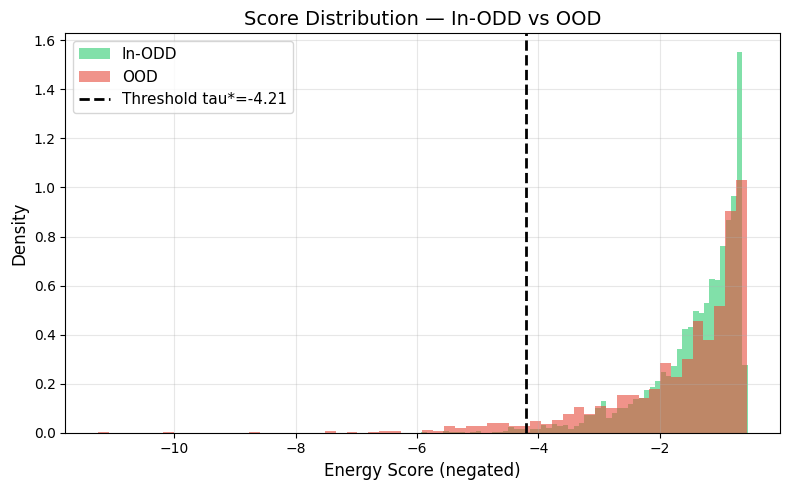

In [ ]:
# ---- 14b. Score Distributions (Energy Score) ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(best_score[labels == 0], bins=60, alpha=0.6, label='In-ODD', color='#2ecc71', density=True)
ax.hist(best_score[labels == 1], bins=60, alpha=0.6, label='OOD', color='#e74c3c', density=True)
ax.axvline(tau_star, color='black', linestyle='--', linewidth=2, label=f'Threshold tau*={tau_star:.2f}')
ax.set_xlabel('Energy Score (negated)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution — In-ODD vs OOD', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

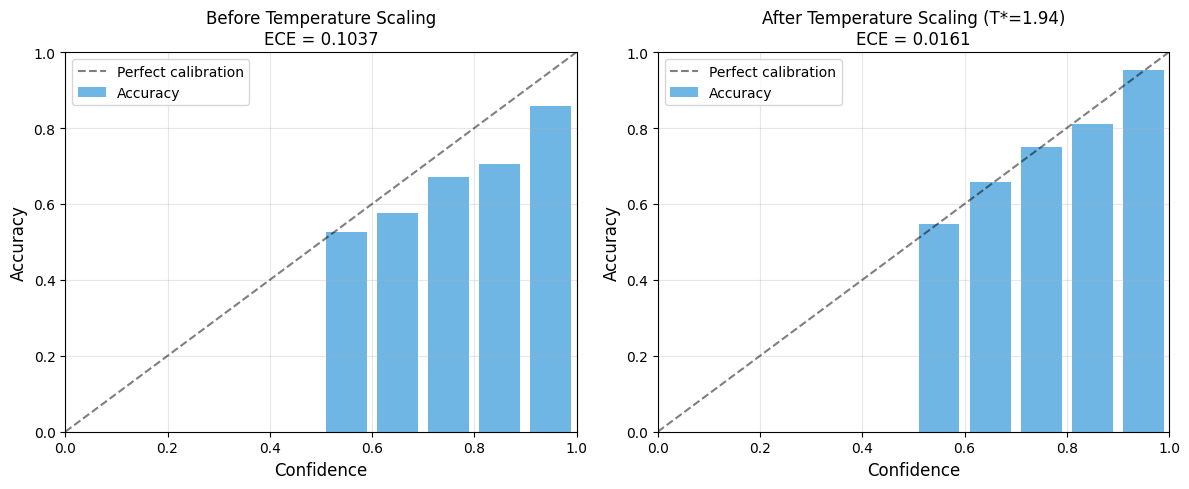

In [ ]:
# ---- 14c. Reliability Diagram (Before vs After Calibration) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, probs, title, ece_val in [
    (ax1, scores['probs_uncalibrated'], 'Before Temperature Scaling', ece_before),
    (ax2, scores['probs_calibrated'], f'After Temperature Scaling (T*={optimal_temp:.2f})', ece_after),
]:
    _, bin_accs, bin_confs, bin_counts = compute_ece(probs, labels, n_bins=10)
    bin_centers = np.linspace(0.05, 0.95, 10)

    ax.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, color='#3498db', label='Accuracy')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{title}\nECE = {ece_val:.4f}', fontsize=12)
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reliability_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

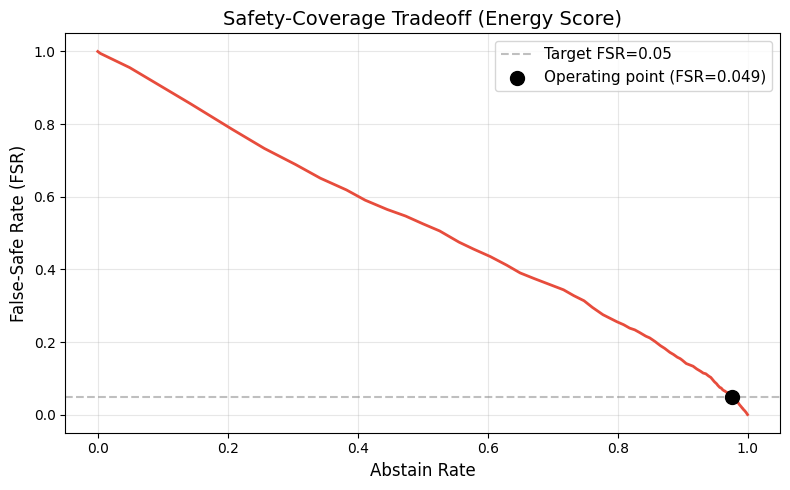

In [ ]:
# ---- 14d. FSR vs Abstain Rate Tradeoff ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(abstain_arr, fsr_arr, linewidth=2, color='#e74c3c')
ax.axhline(target_fsr, color='gray', linestyle='--', alpha=0.5, label=f'Target FSR={target_fsr}')

# Mark operating point
if valid.any():
    ax.scatter([abstain_arr[best_idx]], [fsr_arr[best_idx]],
               s=100, c='black', zorder=5, label=f'Operating point (FSR={fsr_arr[best_idx]:.3f})')

ax.set_xlabel('Abstain Rate', fontsize=12)
ax.set_ylabel('False-Safe Rate (FSR)', fontsize=12)
ax.set_title('Safety-Coverage Tradeoff (Energy Score)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fsr_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

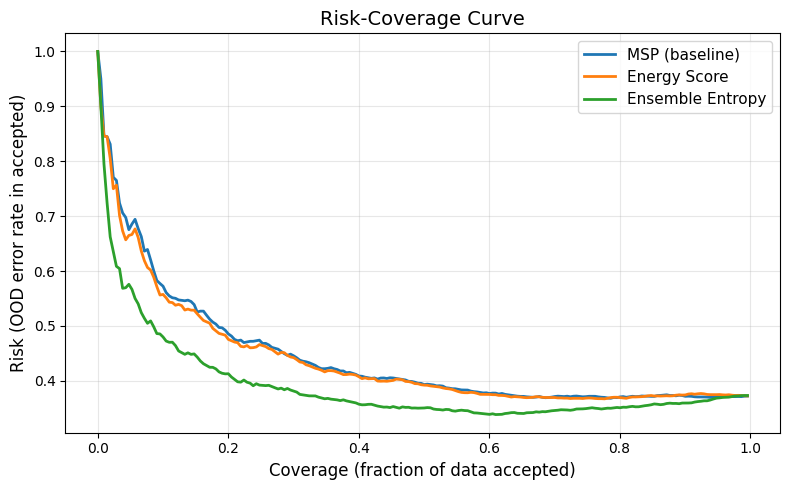

In [ ]:
# ---- 14e. Risk-Coverage Curve ----
def risk_coverage_curve(labels, ood_score):
    """Compute risk (error rate) at each coverage level."""
    # Sort by confidence (ascending OOD score = most confident first)
    order = np.argsort(ood_score)
    sorted_labels = labels[order]

    # Predictions: accept as In-ODD
    coverages, risks = [], []
    n = len(labels)
    for k in range(1, n + 1, max(1, n // 200)):
        accepted = sorted_labels[:k]
        coverage = k / n
        risk = (accepted == 1).mean()  # fraction of OOD in accepted
        coverages.append(coverage)
        risks.append(risk)

    return np.array(coverages), np.array(risks)


fig, ax = plt.subplots(figsize=(8, 5))

for name, s in [('MSP (baseline)', ood_scores['MSP (baseline)']),
                ('Energy Score', ood_scores['Energy Score']),
                ('Ensemble Entropy', ood_scores['Ensemble Entropy'])]:
    cov, risk = risk_coverage_curve(labels, s)
    ax.plot(cov, risk, linewidth=2, label=name)

ax.set_xlabel('Coverage (fraction of data accepted)', fontsize=12)
ax.set_ylabel('Risk (OOD error rate in accepted)', fontsize=12)
ax.set_title('Risk-Coverage Curve', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('risk_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

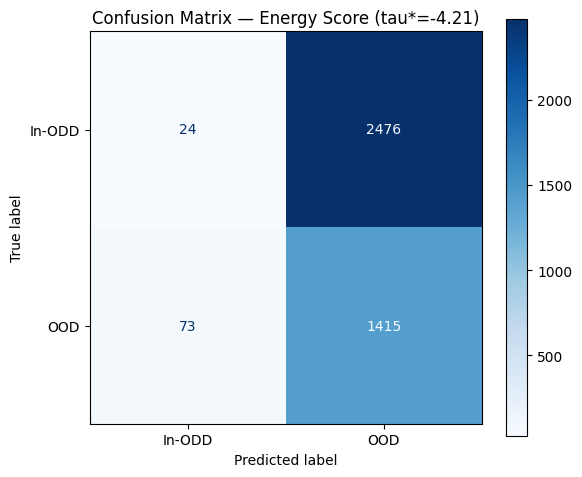

Gate Accuracy: 0.3608


In [ ]:
# ---- 14f. Confusion Matrix ----
# Using Energy Score at optimal threshold
preds = (best_score > tau_star).astype(int)  # 1 = OOD (abstain)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['In-ODD', 'OOD'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — Energy Score (tau*={tau_star:.2f})', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

acc = accuracy_score(labels, preds)
print(f'Gate Accuracy: {acc:.4f}')

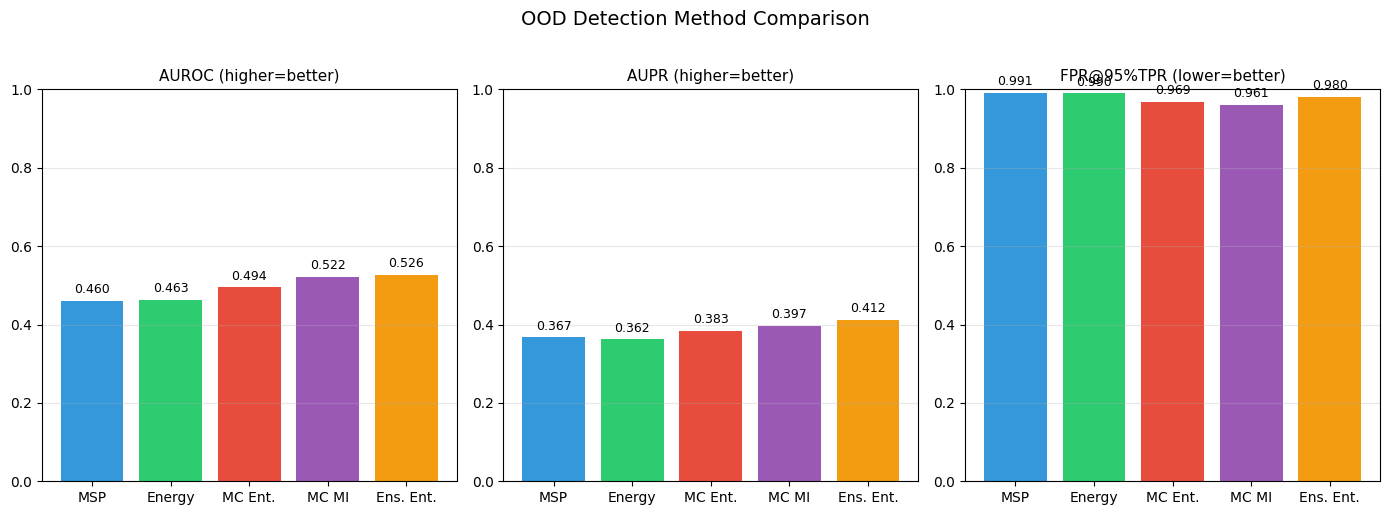

In [ ]:
# ---- 14g. Method Comparison Bar Chart ----
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
methods = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for ax, metric, title in zip(axes, ['auroc', 'aupr', 'fpr95'],
                              ['AUROC (higher=better)', 'AUPR (higher=better)', 'FPR@95%TPR (lower=better)']):
    vals = [results[m][metric] for m in methods]
    short_names = ['MSP', 'Energy', 'MC Ent.', 'MC MI', 'Ens. Ent.']
    bars = ax.bar(short_names, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.3f}', ha='center', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('OOD Detection Method Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Summary

In [ ]:
print('=' * 65)
print('  ODD + OOD SAFETY GATE — FINAL RESULTS')
print('=' * 65)

print(f'\n  Dataset: BDD100K (weather-classified)')
print(f'  In-ODD: Day + Clear/Overcast ({(labels==0).sum()} val samples)')
print(f'  OOD:    Rain + Fog/Snow      ({(labels==1).sum()} val samples)')

print(f'\n  Backbone: Frozen ResNet-50 (ImageNet pretrained)')
print(f'  Head:     MLP (2048 -> 512 -> 128 -> 2)')
print(f'  Best Val Accuracy: {best_val_acc:.4f}')

print(f'\n  --- OOD Detection ---')
print(f'  {"Method":<25} {"AUROC":>7} {"AUPR":>7} {"FPR@95":>8}')
print(f'  {"-"*50}')
for name, r in results.items():
    print(f'  {name:<25} {r["auroc"]:>7.4f} {r["aupr"]:>7.4f} {r["fpr95"]:>8.4f}')

print(f'\n  --- Calibration ---')
print(f'  Temperature T* = {optimal_temp:.4f}')
print(f'  ECE:   {ece_before:.4f} -> {ece_after:.4f}')
print(f'  Brier: {brier_before:.4f} -> {brier_after:.4f}')

print(f'\n  --- Safety Gate (Energy Score) ---')
print(f'  Threshold tau* = {tau_star:.4f}')
if valid.any():
    print(f'  FSR = {fsr_arr[best_idx]:.4f}')
    print(f'  Abstain Rate = {abstain_arr[best_idx]:.4f}')
print(f'  Gate Accuracy = {acc:.4f}')

print(f'\n{"=" * 65}')
print('  Saved plots: training_curves.png, roc_curves.png,')
print('  score_distribution.png, reliability_diagram.png,')
print('  fsr_tradeoff.png, risk_coverage.png,')
print('  confusion_matrix.png, method_comparison.png')
print(f'{"=" * 65}')

  ODD + OOD SAFETY GATE — FINAL RESULTS

  Dataset: BDD100K (weather-classified)
  In-ODD: Day + Clear/Overcast (2500 val samples)
  OOD:    Rain + Fog/Snow      (1488 val samples)

  Backbone: Frozen ResNet-50 (ImageNet pretrained)
  Head:     MLP (2048 -> 512 -> 128 -> 2)
  Best Val Accuracy: 0.8415

  --- OOD Detection ---
  Method                      AUROC    AUPR   FPR@95
  --------------------------------------------------
  MSP (baseline)             0.4599  0.3671   0.9908
  Energy Score               0.4634  0.3619   0.9896
  MC Dropout Entropy         0.4944  0.3834   0.9688
  MC Mutual Info             0.5222  0.3972   0.9612
  Ensemble Entropy           0.5263  0.4120   0.9804

  --- Calibration ---
  Temperature T* = 1.9397
  ECE:   0.1037 -> 0.0161
  Brier: 0.3602 -> 0.3350

  --- Safety Gate (Energy Score) ---
  Threshold tau* = -4.2126
  FSR = 0.0491
  Abstain Rate = 0.9757
  Gate Accuracy = 0.3608

  Saved plots: training_curves.png, roc_curves.png,
  score_distributi